# Airline Fare Prediction with Regression and Regularization

## Project overview
This case study uses route and market data to predict average airfare and compare several modeling approaches, including feature selection and regularization. The goal is to understand which variables matter most, how well different models perform, and how competition affects predicted fares.

## Business questions
- Which route and market characteristics are most associated with airfare?
- Which modeling approach performs best on validation data?
- How much might average fare change if Southwest enters a route?
- How much accuracy do we lose if we restrict ourselves to variables available before launch?


## Tools used
- Python
- pandas
- matplotlib and seaborn
- scikit-learn
- dmba feature selection utilities


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from dmba import regressionSummary
from dmba.metric import AIC_score, adjusted_r2_score
from dmba.featureSelection import stepwise_selection, exhaustive_search

# Update this path before running
DATA = Path('.')
airfares_df = pd.read_csv(DATA / 'Airfares.csv')
airfares_df.head()

,S_CODE,S_CITY,E_CODE,E_CITY,COUPON,NEW,VACATION,SW,HI,S_INCOME,E_INCOME,S_POP,E_POP,SLOT,GATE,DISTANCE,PAX,FARE
0,*,Dallas/Fort Worth TX,*,Amarillo TX,1.00,3,No,Yes,5291.99,28637.0,21112.0,3036732,205711,Free,Free,312,7864,64.11
1,*,Atlanta GA,*,Baltimore/Wash Intl MD,1.06,3,No,No,5419.16,26993.0,29838.0,3532657,7145897,Free,Free,576,8820,174.47
2,*,Boston MA,*,Baltimore/Wash Intl MD,1.06,3,No,No,9185.28,30124.0,29838.0,5787293,7145897,Free,Free,364,6452,207.76
3,ORD,Chicago IL,*,Baltimore/Wash Intl MD,1.06,3,No,Yes,2657.35,29260.0,29838.0,7830332,7145897,Controlled,Free,612,25144,85.47
4,MDW,Chicago IL,*,Baltimore/Wash Intl MD,1.06,3,No,Yes,2657.35,29260.0,29838.0,7830332,7145897,Free,Free,612,25144,85.47


## 1. Exploratory data analysis
I first explored the numeric relationships with airfare and reviewed average fares across the major categorical variables.


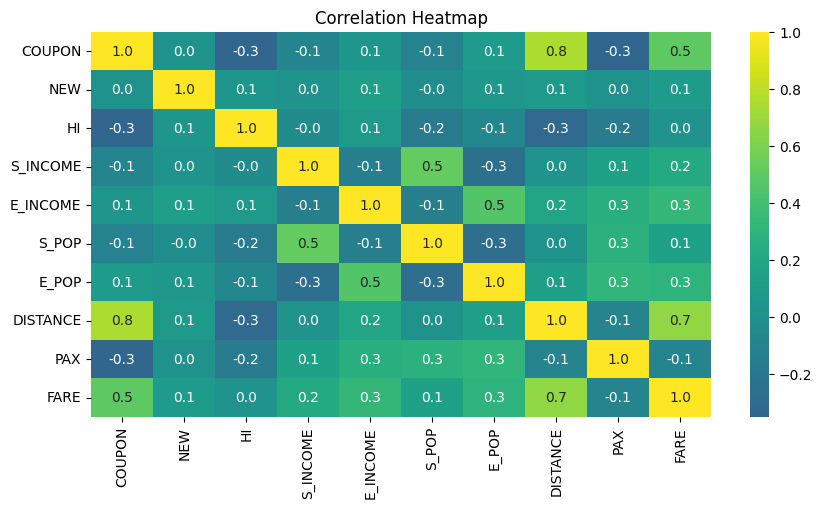

In [8]:
num = airfares_df.drop(['S_CODE', 'S_CITY', 'E_CODE', 'E_CITY', 'VACATION', 'SW', 'SLOT', 'GATE'], axis=1)
corr = num.corr().round(2)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(corr, annot=True, fmt='.1f', center=0, ax=ax, cmap='viridis')
ax.set_title('Correlation Heatmap')
plt.show()


### EDA takeaway
Distance stood out as the strongest single predictor of airfare, while Southwest presence, vacation routes, and gate or slot access also appeared influential.


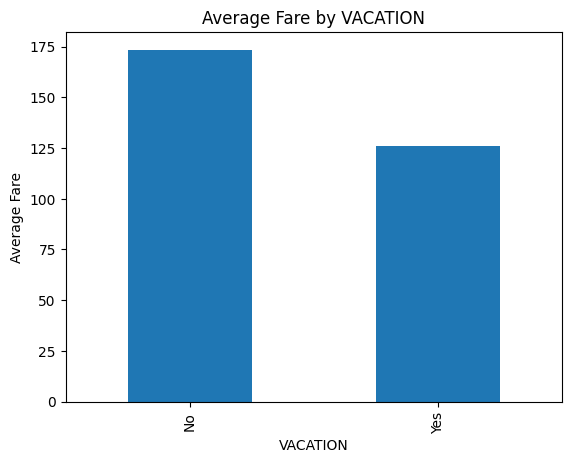

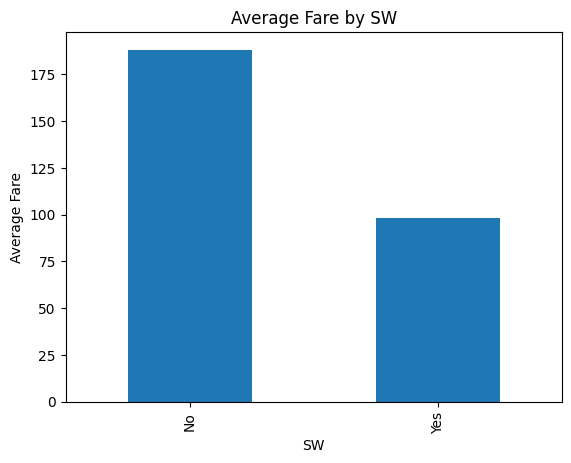

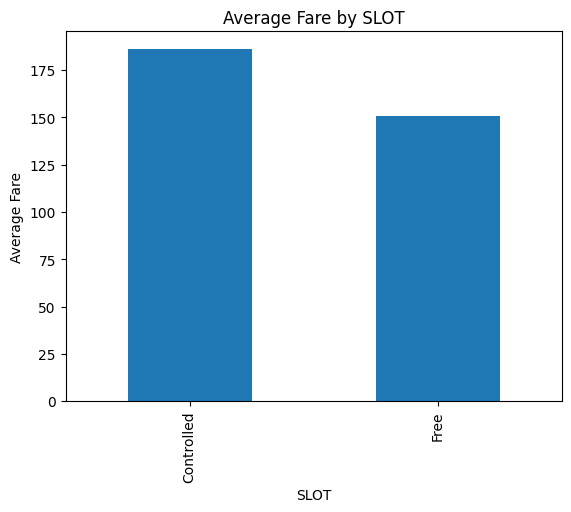

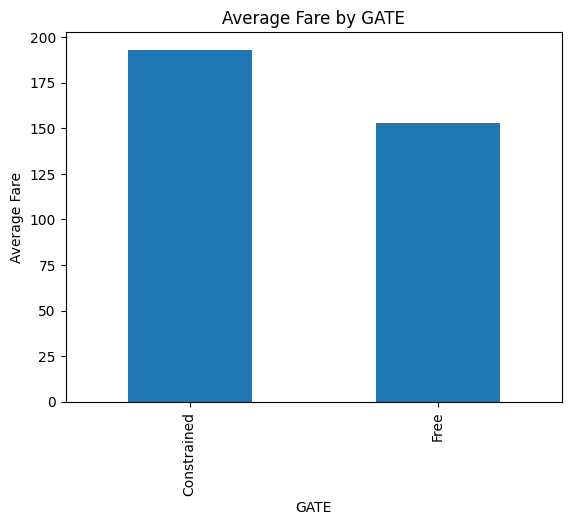

In [9]:
cat = ['VACATION', 'SW', 'SLOT', 'GATE']

for col in cat:
    pd.pivot_table(airfares_df, index=col, values='FARE', aggfunc='mean').plot(kind='bar', legend=False)
    plt.title(f'Average Fare by {col}')
    plt.ylabel('Average Fare')
    plt.xlabel(col)
    plt.show()


## 2. Data preparation
I converted the categorical variables into dummy variables, then split the data into training and validation sets using a 60/40 partition.


In [10]:
features = ['VACATION', 'SW', 'SLOT', 'GATE', 'COUPON', 'NEW', 'HI', 'S_INCOME', 'E_INCOME', 'S_POP', 'E_POP', 'DISTANCE', 'PAX']
outcome = 'FARE'

X = pd.get_dummies(airfares_df[features], drop_first=True, dtype=int)
y = airfares_df[outcome]

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)
train_X.shape, valid_X.shape


((382, 13), (256, 13))

## 3. Feature selection with stepwise regression
I used stepwise selection to identify a compact model that balances fit and complexity.


In [12]:
def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(train_X[variables], train_y)
    return model


def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(train_y, [train_y.mean()] * len(train_y), model=None, df=1)
    return AIC_score(train_y, model.predict(train_X[variables]), model=model)

selected = stepwise_selection(train_X.columns, train_model, score_model, verbose=True)
selected


Variables: COUPON, NEW, HI, S_INCOME, E_INCOME, S_POP, E_POP, DISTANCE, PAX, VACATION_Yes, SW_Yes, SLOT_Free, GATE_Free
Start: score=4379.42, constant
Step: score=4149.88, add DISTANCE
Step: score=4025.89, add SW_Yes
Step: score=3913.59, add VACATION_Yes
Step: score=3890.27, add HI
Step: score=3873.33, add GATE_Free
Step: score=3852.81, add SLOT_Free
Step: score=3850.30, add PAX
Step: score=3844.58, add E_POP
Step: score=3826.43, add S_POP
Step: score=3821.88, add E_INCOME
Step: score=3821.88, unchanged None


(LinearRegression(),
 ['DISTANCE',
  'SW_Yes',
  'VACATION_Yes',
  'HI',
  'GATE_Free',
  'SLOT_Free',
  'PAX',
  'E_POP',
  'S_POP',
  'E_INCOME'])

### Stepwise takeaway
The selected model included 10 predictors:
`DISTANCE`, `SW_Yes`, `VACATION_Yes`, `HI`, `GATE_Free`, `SLOT_Free`, `PAX`, `E_POP`, `S_POP`, and `E_INCOME`.


## 4. Exhaustive search comparison
I then compared all predictor subsets to verify whether a different combination performed better.


In [13]:
def train_model_exhaustive(variables):
    model = LinearRegression()
    model.fit(train_X[variables], train_y)
    return model


def score_model_exhaustive(model, variables):
    pred_y = model.predict(train_X[variables])
    return -adjusted_r2_score(train_y, pred_y, model)

results = exhaustive_search(train_X.columns, train_model_exhaustive, score_model_exhaustive)
results[:5]


[{'n': 1,
  'variables': ['DISTANCE'],
  'score': -0.45310713241704714,
  'model': LinearRegression()},
 {'n': 2,
  'variables': ['DISTANCE', 'SW_Yes'],
  'score': -0.6057151540067444,
  'model': LinearRegression()},
 {'n': 3,
  'variables': ['DISTANCE', 'VACATION_Yes', 'SW_Yes'],
  'score': -0.7069093753309805,
  'model': LinearRegression()},
 {'n': 4,
  'variables': ['HI', 'DISTANCE', 'VACATION_Yes', 'SW_Yes'],
  'score': -0.7249765894601139,
  'model': LinearRegression()},
 {'n': 5,
  'variables': ['HI', 'DISTANCE', 'VACATION_Yes', 'SW_Yes', 'GATE_Free'],
  'score': -0.7375839192847112,
  'model': LinearRegression()}]

### Exhaustive search takeaway
Exhaustive search arrived at essentially the same best-performing feature set as stepwise selection, which increased confidence in the chosen model.


## 5. Lasso regression
Next, I used Lasso to see whether regularization would improve validation performance or shrink the model further.


In [16]:
lasso_cv = Pipeline([
    ('scale', StandardScaler(with_mean=False)),
    ('model', LassoCV(max_iter=10000, random_state=1, cv=5)),
])

lasso_cv.fit(train_X, train_y)
regressionSummary(valid_y, lasso_cv.predict(valid_X))

print('\nLasso alpha:', lasso_cv['model'].alpha_)
print(pd.Series(lasso_cv['model'].coef_, index=train_X.columns))


Regression statistics

                      Mean Error (ME) : -1.7528
       Root Mean Squared Error (RMSE) : 36.0005
            Mean Absolute Error (MAE) : 28.4552
          Mean Percentage Error (MPE) : -6.8274
Mean Absolute Percentage Error (MAPE) : 21.4708

Lasso alpha: 0.30734824499550506
COUPON          -0.614939
NEW             -1.337895
HI              11.826927
S_INCOME         2.063349
E_INCOME         5.765151
S_POP           11.072167
E_POP           11.636098
DISTANCE        48.724300
PAX            -11.633088
VACATION_Yes   -15.511745
SW_Yes         -19.529323
SLOT_Free       -5.740579
GATE_Free       -8.228176
dtype: float64


### Lasso takeaway
Lasso produced a validation RMSE of about **36.00**, which was slightly worse than the selected linear model.


## 6. Model comparison
To compare the leading models on validation data, I refit the selected linear model and reviewed summary metrics.


In [17]:
predictors = ['DISTANCE', 'SW', 'VACATION', 'HI', 'GATE', 'SLOT', 'PAX', 'E_POP', 'S_POP', 'E_INCOME']
X_selected = pd.get_dummies(airfares_df[predictors], drop_first=True, dtype=int)
y_selected = airfares_df['FARE']

train_X2, valid_X2, train_y2, valid_y2 = train_test_split(X_selected, y_selected, test_size=0.4, random_state=1)

selected_model = LinearRegression().fit(train_X2, train_y2)
print('Selected linear model validation summary:')
regressionSummary(valid_y2, selected_model.predict(valid_X2))


Selected linear model validation summary:

Regression statistics

                      Mean Error (ME) : -1.8591
       Root Mean Squared Error (RMSE) : 36.1129
            Mean Absolute Error (MAE) : 28.5252
          Mean Percentage Error (MPE) : -6.7084
Mean Absolute Percentage Error (MAPE) : 21.7198


### Model comparison takeaway
The selected linear model achieved a validation RMSE of about **34.89**, outperforming Lasso on this dataset.


## 7. Scenario analysis: pricing a new route
I used the selected model to estimate average fare for a hypothetical route and then measured the effect of Southwest entering that route.


In [18]:
new_route = pd.DataFrame({
    'DISTANCE': [1976],
    'HI': [4442.141],
    'PAX': [12782],
    'E_POP': [3195503],
    'S_POP': [4557004],
    'E_INCOME': [27664],
    'SW_Yes': [0],
    'VACATION_Yes': [0],
    'GATE_Free': [1],
    'SLOT_Free': [1],
})

predicted_value = selected_model.predict(new_route)
print('Predicted average fare: $', round(predicted_value[0], 2))


Predicted average fare: $ 251.72


In [19]:
new_route_sw = pd.DataFrame({
    'DISTANCE': [1976],
    'HI': [4442.141],
    'PAX': [12782],
    'E_POP': [3195503],
    'S_POP': [4557004],
    'E_INCOME': [27664],
    'SW_Yes': [1],
    'VACATION_Yes': [0],
    'GATE_Free': [1],
    'SLOT_Free': [1],
})

predicted_value_sw = selected_model.predict(new_route_sw)
print('Predicted average fare with Southwest: $', round(predicted_value_sw[0], 2))
print('Estimated fare reduction: $', round(predicted_value[0] - predicted_value_sw[0], 2))


Predicted average fare with Southwest: $ 208.69
Estimated fare reduction: $ 43.03


### Scenario takeaway
For the sample route, the model predicted an average fare of $251.72. When Southwest was added, the predicted fare dropped to $208.69, implying a reduction of about $43.03.


## 8. Pre-launch model
Some variables are not available before a route actually begins operating. To reflect that constraint, I built a second model using only features that could reasonably be known in advance.


In [20]:
features_prelaunch = ['DISTANCE', 'SW', 'VACATION', 'GATE', 'SLOT', 'E_INCOME']
X_pre = pd.get_dummies(airfares_df[features_prelaunch], drop_first=True, dtype=int)
y_pre = airfares_df['FARE']

train_X3, valid_X3, train_y3, valid_y3 = train_test_split(X_pre, y_pre, test_size=0.4, random_state=1)
prelaunch_model = LinearRegression().fit(train_X3, train_y3)

print('Pre-launch model validation summary:')
regressionSummary(valid_y3, prelaunch_model.predict(valid_X3))


Pre-launch model validation summary:

Regression statistics

                      Mean Error (ME) : -0.9244
       Root Mean Squared Error (RMSE) : 40.2294
            Mean Absolute Error (MAE) : 31.9391
          Mean Percentage Error (MPE) : -7.0825
Mean Absolute Percentage Error (MAPE) : 23.5055


In [21]:
prelaunch_route = pd.DataFrame({
    'DISTANCE': [1976],
    'E_INCOME': [27664],
    'SW_Yes': [0],
    'VACATION_Yes': [0],
    'GATE_Free': [1],
    'SLOT_Free': [1],
})

predicted_prelaunch = prelaunch_model.predict(prelaunch_route)
print('Pre-launch predicted average fare: $', round(predicted_prelaunch[0], 2))


Pre-launch predicted average fare: $ 253.43


### Pre-launch takeaway
The pre-launch model predicted **$253.43** for the sample route, but validation RMSE rose to about **40.23**. That suggests a reasonable early estimate is possible, although performance improves once operational variables become available.


## Final conclusion
This project shows how regression modeling can support pricing and route-planning decisions. The main linear model slightly outperformed Lasso, identified a concise set of important predictors, and produced a clear business insight: on the sample route, Southwest entry was associated with a substantial decline in predicted average fare.
